In [70]:
import pandas as pd
import numpy as np

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [71]:
print(train.shape, test.shape)

(1460, 81) (1459, 80)


In [72]:
train["Alley"] = train["Alley"].fillna("NoAlley")
test["Alley"] = test["Alley"].fillna("NoAlley")

In [73]:
# Missing value summary for train
train_na = train.isnull().sum().sort_values(ascending=False)
train_na = train_na[train_na > 0]
print("Train missing values:\n", train_na)

# Missing value summary for test
test_na = test.isnull().sum().sort_values(ascending=False)
test_na = test_na[test_na > 0]
print("\nTest missing values:\n", test_na)

Train missing values:
 PoolQC          1453
MiscFeature     1406
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageQual        81
GarageCond        81
GarageFinish      81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
BsmtFinType1      37
BsmtCond          37
MasVnrArea         8
Electrical         1
dtype: int64

Test missing values:
 PoolQC          1456
MiscFeature     1408
Fence           1169
MasVnrType       894
FireplaceQu      730
LotFrontage      227
GarageCond        78
GarageYrBlt       78
GarageFinish      78
GarageQual        78
GarageType        76
BsmtCond          45
BsmtQual          44
BsmtExposure      44
BsmtFinType2      42
BsmtFinType1      42
MasVnrArea        15
MSZoning           4
BsmtHalfBath       2
Utilities          2
Functional         2
BsmtFullBath       2
BsmtFinSF1         1
BsmtFinSF2         1
TotalBsmtSF        1
KitchenQual        1
BsmtUnfSF        

In [74]:
fill_dict_train = {
    "PoolQC": "NoPool",
    "MiscFeature": "None",
    "Alley": "NoAlley",
    "Fence": "NoFence",
    "FireplaceQu": "NoFireplace",
    "MasVnrType": "None",
    "Electrical": train["Electrical"].mode()[0]  # only 1 missing
}

for col, val in fill_dict_train.items():
    train[col] = train[col].fillna(val)

In [75]:
num_fill_train = {
    "LotFrontage": train["LotFrontage"].median(),
    "GarageYrBlt": train["GarageYrBlt"].median(),
    "MasVnrArea": train["MasVnrArea"].median()
}

for col, val in num_fill_train.items():
    train[col] = train[col].fillna(val)

In [76]:
num_fill_test = {
    "LotFrontage": test["LotFrontage"].median(),
    "GarageYrBlt": test["GarageYrBlt"].median(),
    "GarageArea": test["GarageArea"].median()  # only 1 missing
}

for col, val in num_fill_test.items():
    test[col] = test[col].fillna(val)

In [77]:
print(train.isnull().sum().sum())  # should be 0
print(test.isnull().sum().sum())   # should be 0

511
6220


In [78]:
# Train
train_na_remaining = train.isnull().sum()
train_na_remaining = train_na_remaining[train_na_remaining > 0]
print("Remaining Train missing:\n", train_na_remaining)

# Test
test_na_remaining = test.isnull().sum()
test_na_remaining = test_na_remaining[test_na_remaining > 0]
print("\nRemaining Test missing:\n", test_na_remaining)

Remaining Train missing:
 BsmtQual        37
BsmtCond        37
BsmtExposure    38
BsmtFinType1    37
BsmtFinType2    38
GarageType      81
GarageFinish    81
GarageQual      81
GarageCond      81
dtype: int64

Remaining Test missing:
 MSZoning           4
Utilities          2
Exterior1st        1
Exterior2nd        1
MasVnrType       894
MasVnrArea        15
BsmtQual          44
BsmtCond          45
BsmtExposure      44
BsmtFinType1      42
BsmtFinSF1         1
BsmtFinType2      42
BsmtFinSF2         1
BsmtUnfSF          1
TotalBsmtSF        1
BsmtFullBath       2
BsmtHalfBath       2
KitchenQual        1
Functional         2
FireplaceQu      730
GarageType        76
GarageFinish      78
GarageCars         1
GarageQual        78
GarageCond        78
PoolQC          1456
Fence           1169
MiscFeature     1408
SaleType           1
dtype: int64


In [79]:
train_cat_fill = {
    "BsmtQual": "NoBsmt",
    "BsmtCond": "NoBsmt",
    "BsmtExposure": "NoBsmt",
    "BsmtFinType1": "NoBsmt",
    "BsmtFinType2": "NoBsmt",
    "GarageType": "NoGarage",
    "GarageFinish": "NoGarage",
    "GarageQual": "NoGarage",
    "GarageCond": "NoGarage"
}

for col, val in train_cat_fill.items():
    train[col] = train[col].fillna(val)

In [80]:
test_cat_fill = {
    "BsmtQual": "NoBsmt",
    "BsmtCond": "NoBsmt",
    "BsmtExposure": "NoBsmt",
    "BsmtFinType1": "NoBsmt",
    "BsmtFinType2": "NoBsmt",
    "GarageType": "NoGarage",
    "GarageFinish": "NoGarage",
    "GarageQual": "NoGarage",
    "GarageCond": "NoGarage",
    "MasVnrType": "None",
    "Exterior1st": test["Exterior1st"].mode()[0],
    "Exterior2nd": test["Exterior2nd"].mode()[0],
    "MSZoning": test["MSZoning"].mode()[0],
    "Utilities": test["Utilities"].mode()[0],
    "SaleType": test["SaleType"].mode()[0]
}

for col, val in test_cat_fill.items():
    test[col] = test[col].fillna(val)

In [81]:
test_num_fill = {
    "MasVnrArea": test["MasVnrArea"].median(),
    "BsmtFinSF1": test["BsmtFinSF1"].median()
    # add more numeric columns if they still have NA
}

for col, val in test_num_fill.items():
    test[col] = test[col].fillna(val)

In [82]:
print("Train remaining missing:", train.isnull().sum().sum())  # should be 0
print("Test remaining missing:", test.isnull().sum().sum())    # should be very low, maybe only weird edge cases

Train remaining missing: 0
Test remaining missing: 4774


In [83]:
high_na_test_fill = {
    "PoolQC": "NoPool",
    "MiscFeature": "None",
    "Fence": "NoFence",
    "MasVnrType": "None",
    "FireplaceQu": "NoFireplace"
}

for col, val in high_na_test_fill.items():
    test[col] = test[col].fillna(val)

In [84]:
small_num_fill = {
    "MasVnrArea": test["MasVnrArea"].median(),
    "LotFrontage": test["LotFrontage"].median(),
    "GarageArea": test["GarageArea"].median(),
    "BsmtFinSF1": test["BsmtFinSF1"].median(),
    "BsmtFinSF2": test["BsmtFinSF2"].median(),
    "BsmtUnfSF": test["BsmtUnfSF"].median(),
    "TotalBsmtSF": test["TotalBsmtSF"].median(),
    "BsmtFullBath": test["BsmtFullBath"].median(),
    "BsmtHalfBath": test["BsmtHalfBath"].median()
}

for col, val in small_num_fill.items():
    test[col] = test[col].fillna(val)

In [85]:
print("Train remaining missing:", train.isnull().sum().sum())  # should be 0
print("Test remaining missing:", test.isnull().sum().sum())    # should be very close to 0

Train remaining missing: 0
Test remaining missing: 4


In [86]:
# Fix last missing values in test
test["KitchenQual"] = test["KitchenQual"].fillna(test["KitchenQual"].mode()[0])
test["Functional"] = test["Functional"].fillna(test["Functional"].mode()[0])
test["GarageCars"] = test["GarageCars"].fillna(test["GarageCars"].median())

In [87]:
print("Train remaining missing:", train.isnull().sum().sum())  # should be 0
print("Test remaining missing:", test.isnull().sum().sum())    # should be very close to 0

Train remaining missing: 0
Test remaining missing: 0


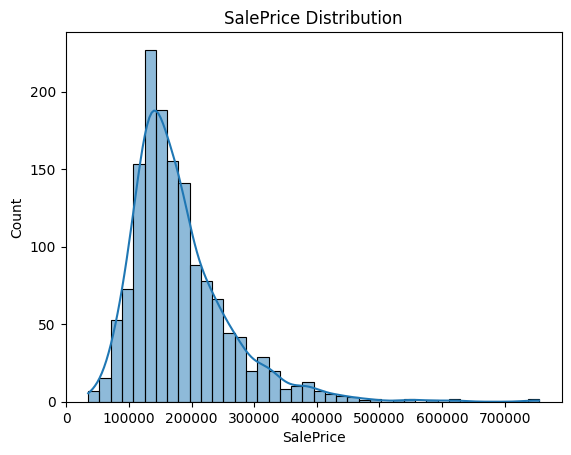

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(train["SalePrice"], kde=True, bins=40)
plt.title("SalePrice Distribution")
plt.show()

In [89]:
train["SalePrice"] = np.log1p(train["SalePrice"])

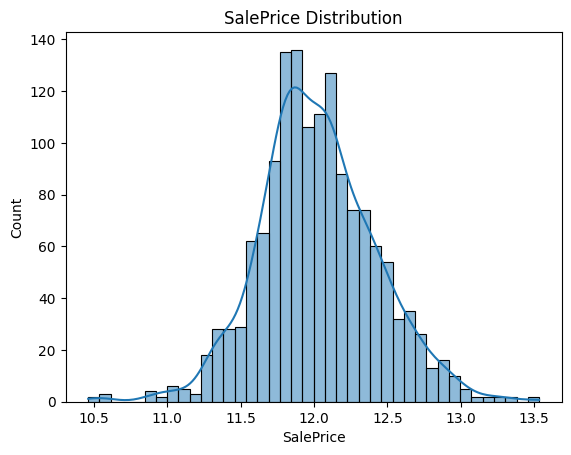

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(train["SalePrice"], kde=True, bins=40)
plt.title("SalePrice Distribution")
plt.show()

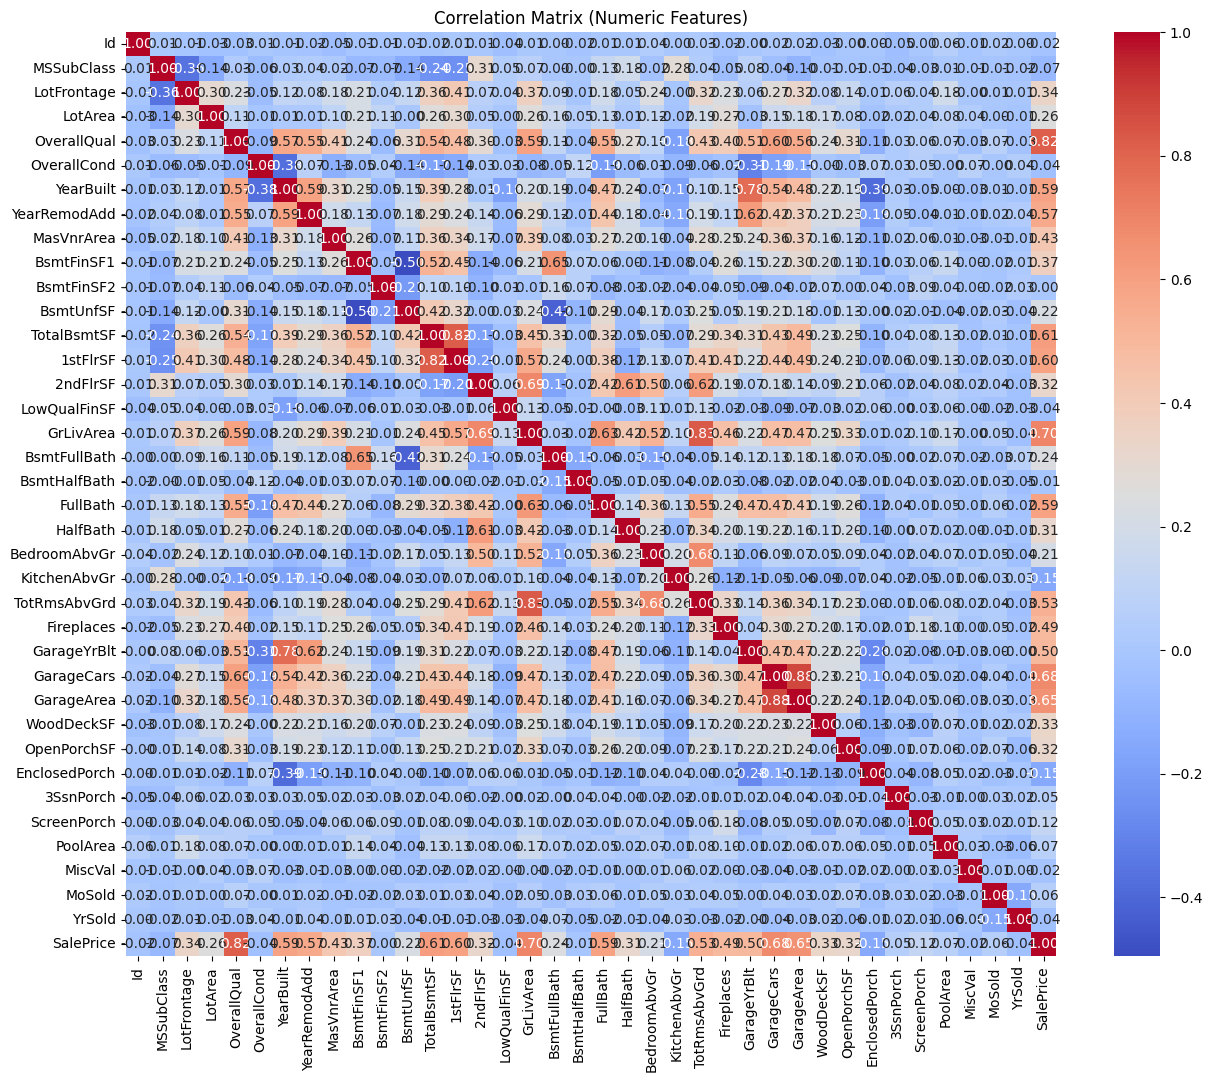

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

# Numeric columns only
numeric_cols = train.select_dtypes(include=['int64', 'float64']).columns

corr_matrix = train[numeric_cols].corr()

plt.figure(figsize=(15,12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix (Numeric Features)")
plt.show()

In [93]:
target_corr = corr_matrix["SalePrice"].sort_values(ascending=False)
print(target_corr)

SalePrice        1.000000
OverallQual      0.817185
GrLivArea        0.700927
GarageCars       0.680625
GarageArea       0.650888
TotalBsmtSF      0.612134
1stFlrSF         0.596981
FullBath         0.594771
YearBuilt        0.586570
YearRemodAdd     0.565608
TotRmsAbvGrd     0.534422
GarageYrBlt      0.495794
Fireplaces       0.489450
MasVnrArea       0.426776
BsmtFinSF1       0.372023
LotFrontage      0.335292
WoodDeckSF       0.334135
OpenPorchSF      0.321053
2ndFlrSF         0.319300
HalfBath         0.313982
LotArea          0.257320
BsmtFullBath     0.236224
BsmtUnfSF        0.221985
BedroomAbvGr     0.209043
ScreenPorch      0.121208
PoolArea         0.069798
MoSold           0.057330
3SsnPorch        0.054900
BsmtFinSF2       0.004832
BsmtHalfBath    -0.005149
Id              -0.017942
MiscVal         -0.020021
OverallCond     -0.036868
YrSold          -0.037263
LowQualFinSF    -0.037963
MSSubClass      -0.073959
KitchenAbvGr    -0.147548
EnclosedPorch   -0.149050
Name: SalePr

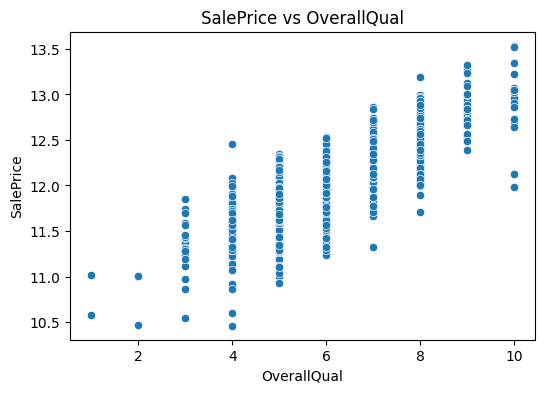

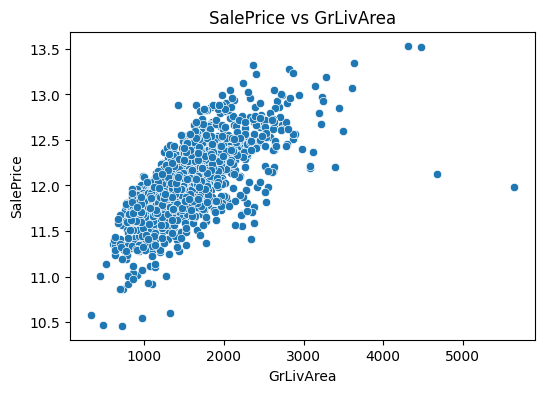

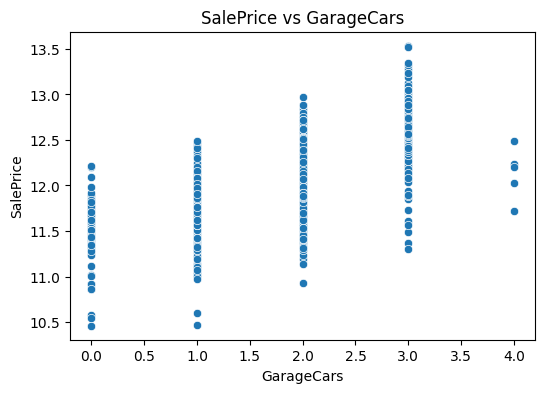

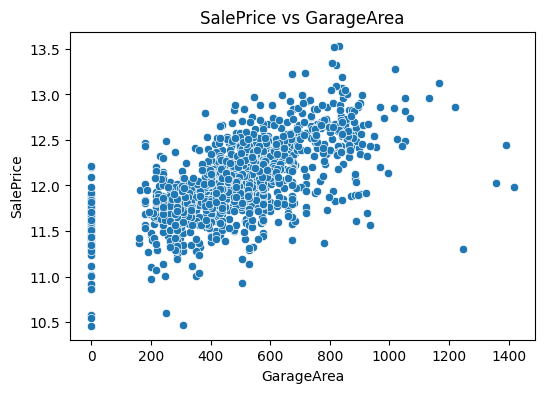

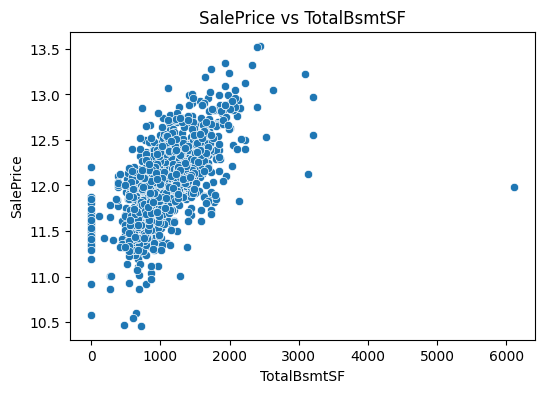

In [94]:
top_features = target_corr[1:6].index  # top 5 features besides SalePrice

import matplotlib.pyplot as plt
import seaborn as sns

for col in top_features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=train, x=col, y="SalePrice")
    plt.title(f"SalePrice vs {col}")
    plt.show()

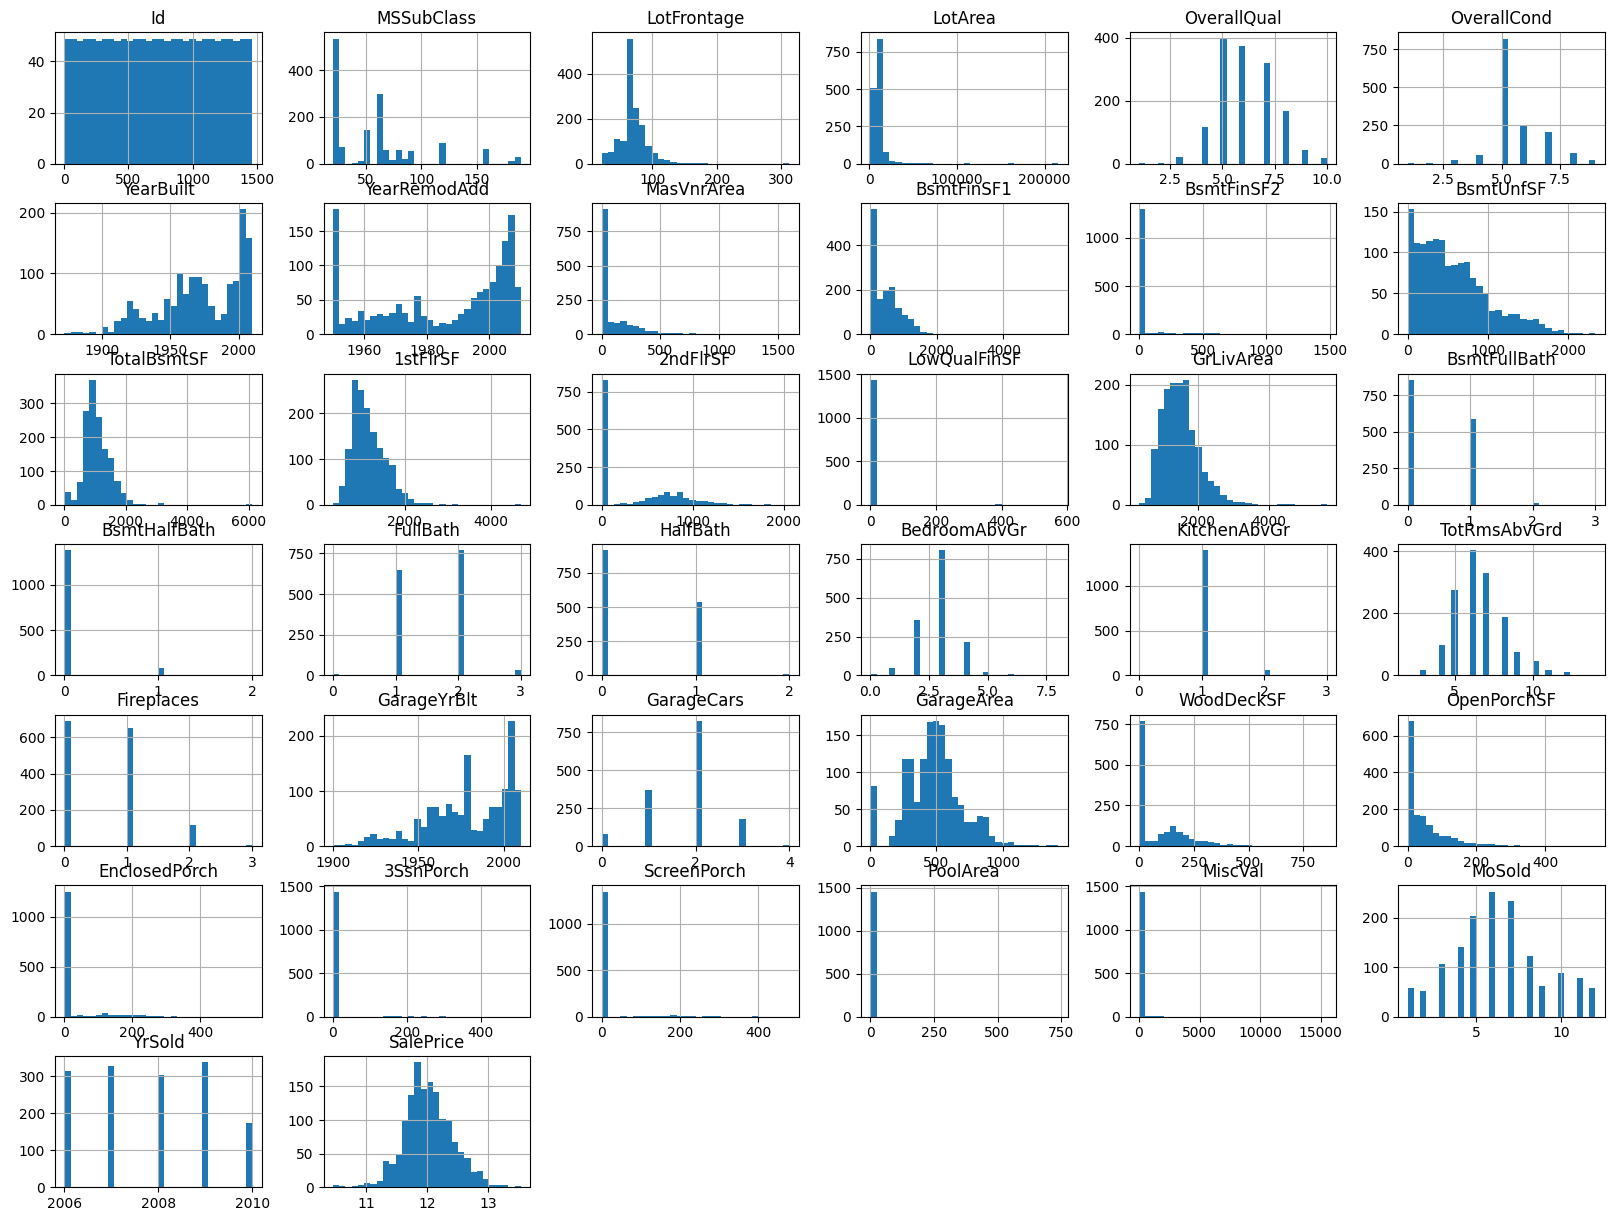

In [95]:
num_cols = train.select_dtypes(include=['int64','float64']).columns

train[num_cols].hist(figsize=(20,15), bins=30)
plt.show()

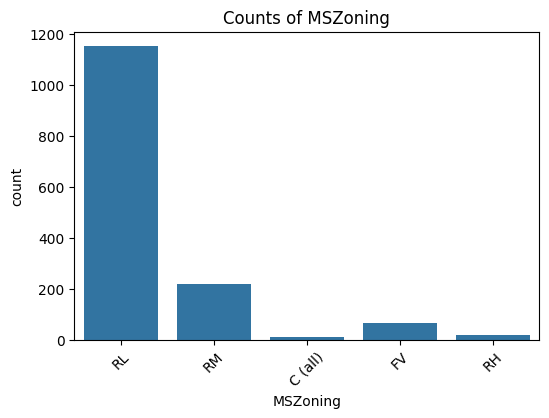

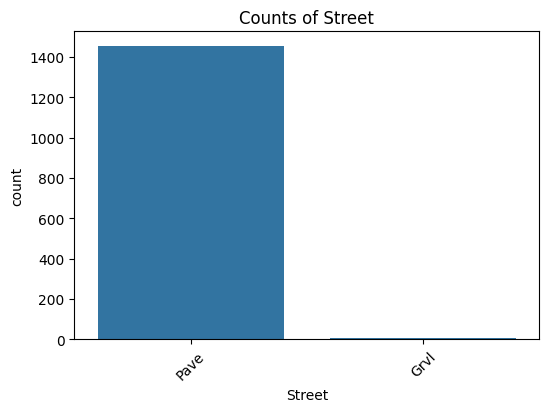

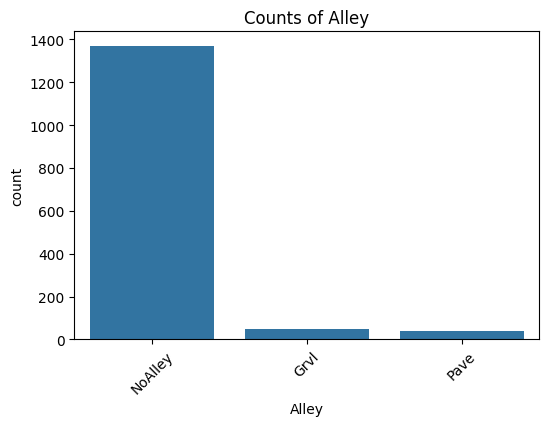

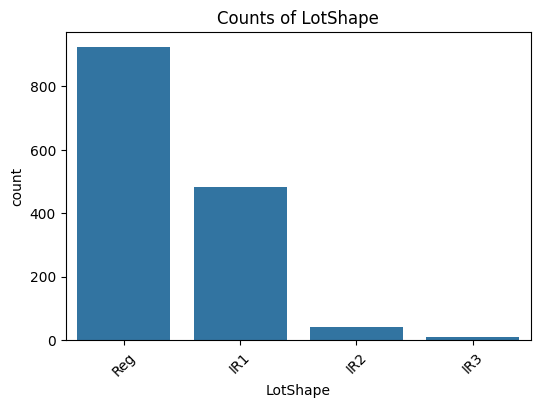

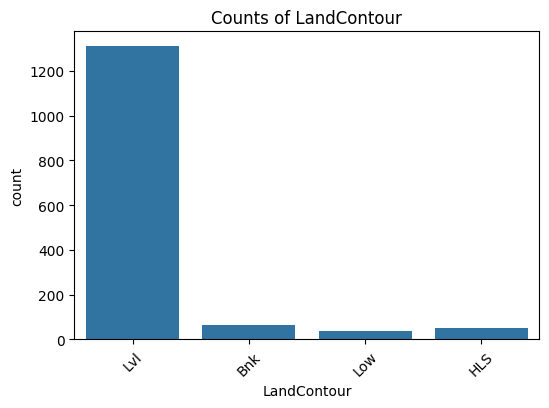

In [97]:
for col in cat_cols[:5]:  # just first 5 to avoid massive plots
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=train)
    plt.title(f"Counts of {col}")
    plt.xticks(rotation=45)
    plt.show()

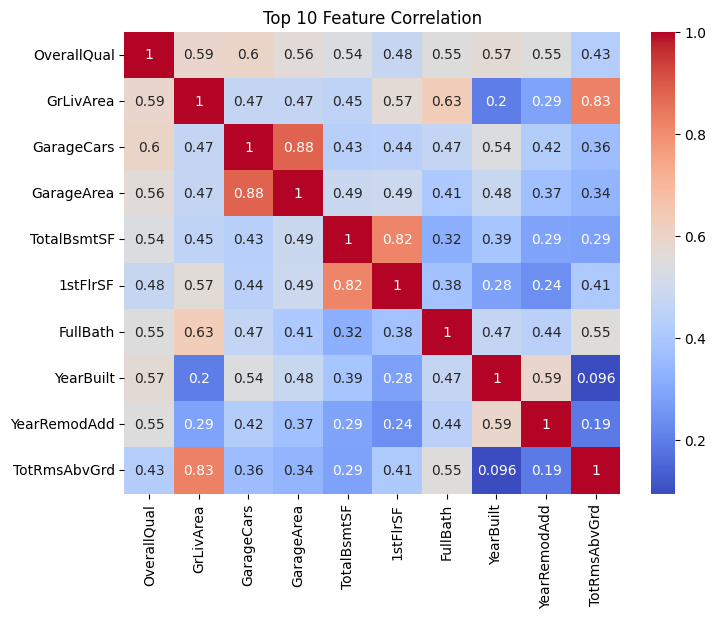

In [98]:
top_corr_features = target_corr[1:11].index
plt.figure(figsize=(8,6))
sns.heatmap(train[top_corr_features].corr(), annot=True, cmap="coolwarm")
plt.title("Top 10 Feature Correlation")
plt.show()

In [99]:
# Save cleaned datasets
train.to_csv("train_cleaned.csv", index=False)
test.to_csv("test_cleaned.csv", index=False)